This is a simple notebook to illustrate the behavior of generalized linear models.  
It accompanies Chapter 5 of the book (5 of 5).  
Copyright: Viviana Acquaviva (2023); see however data credits below.  
Modifications by Aaron Romanowsky
License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

In [2]:
import matplotlib
font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 
matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

The data used for this example come from here:

https://bitbucket.org/vandenbe/sea_level_final/src/master/

and we are trying to reproduce results from [Vanderberg-Rodes et al, 2016](https://ui.adsabs.harvard.edu/abs/2016JGRC..121.8008V/abstract).

In [3]:
x = loadmat('dat.mat')
x

{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Mon Aug 24 19:49:13 2015',
 '__version__': '1.0',
 '__globals__': [],
 'Dat': array([[   nan,    nan,    nan, ...,  0.   ,  0.213,  9.   ],
        [ 0.046,  0.   ,    nan, ...,  0.   ,  0.166,  0.   ],
        [ 0.02 ,  0.   ,    nan, ...,  0.   ,  0.127,  0.   ],
        ...,
        [ 0.33 ,  7.   ,  0.508, ...,  1.   ,  0.211,  4.   ],
        [ 0.312, 14.   ,  0.482, ...,  8.   ,  0.214,  3.   ],
        [ 0.303, 13.   ,  0.45 , ...,  0.   ,  0.228,  3.   ]],
       shape=(94, 36)),
 'Years': array([[1920],
        [1921],
        [1922],
        [1923],
        [1924],
        [1925],
        [1926],
        [1927],
        [1928],
        [1929],
        [1930],
        [1931],
        [1932],
        [1933],
        [1934],
        [1935],
        [1936],
        [1937],
        [1938],
        [1939],
        [1940],
        [1941],
        [1942],
        [1943],
        [1944],
        [1945],
        [1946]

The data consist of a dictionary with the variables and values contained in the MAT-file. The sea level and nuisance flooding will be, respectively, our feature and target.

In [4]:
sealev = x['Dat'][:,::2] # sea level
NF = x['Dat'][:,1::2] # nuisance flooding
sealev

array([[  nan,   nan,   nan, ...,   nan, 0.033, 0.213],
       [0.046,   nan,   nan, ...,   nan, 0.041, 0.166],
       [0.02 ,   nan,   nan, ...,   nan, 0.015, 0.127],
       ...,
       [0.33 , 0.508, 0.411, ..., 0.243, 0.221, 0.211],
       [0.312, 0.482, 0.392, ..., 0.26 , 0.258, 0.214],
       [0.303, 0.45 , 0.373, ..., 0.289, 0.169, 0.228]], shape=(94, 18))

In [5]:
NF.shape, sealev.shape

((94, 18), (94, 18))

Load features (one features for each station!) - note that for early years, many data are missing.

In [6]:
data = pd.DataFrame(sealev, columns = [el[0][0] for el in x['varlist']], index = [el[0] for el in x['Years']])
data.head()

,BMA,BNY,SNJ,ANJ,PPA,BMD,AMD,WDC,SVA,WNC,CSC,FGA,KFL,LCA,SCA,PTX,SWA,HHI
1920,NaN,NaN,NaN,NaN,0.098,0.064,NaN,NaN,NaN,NaN,NaN,NaN,0.002,NaN,NaN,NaN,0.033,0.213
1921,0.046,NaN,NaN,NaN,NaN,0.088,NaN,NaN,NaN,NaN,NaN,NaN,0.045,NaN,0.136,NaN,0.041,0.166
1922,0.020,NaN,NaN,NaN,NaN,0.057,NaN,NaN,NaN,NaN,0.050,NaN,0.033,NaN,0.126,NaN,0.015,0.127
1923,0.015,NaN,NaN,0.056,0.044,0.064,NaN,NaN,NaN,NaN,0.030,NaN,0.010,NaN,0.118,NaN,0.035,0.116
1924,0.023,NaN,NaN,0.063,0.078,0.076,NaN,NaN,NaN,NaN,0.052,NaN,0.014,NaN,0.089,NaN,0.003,0.092


Load target (NF hours, one target for each station!)

In [7]:
target = pd.DataFrame(NF, columns = [el[0][0] for el in x['varlist']], index = [el[0] for el in x['Years']])
target.head()

,BMA,BNY,SNJ,ANJ,PPA,BMD,AMD,WDC,SVA,WNC,CSC,FGA,KFL,LCA,SCA,PTX,SWA,HHI
1920,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,9.0
1921,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2.0,NaN,0.0,0.0
1922,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,2.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0
1923,0.0,NaN,NaN,3.0,0.0,4.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0
1924,0.0,NaN,NaN,0.0,0.0,13.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0


### We can plot data for a couple of stations to make sure we read things right (compare with paper).

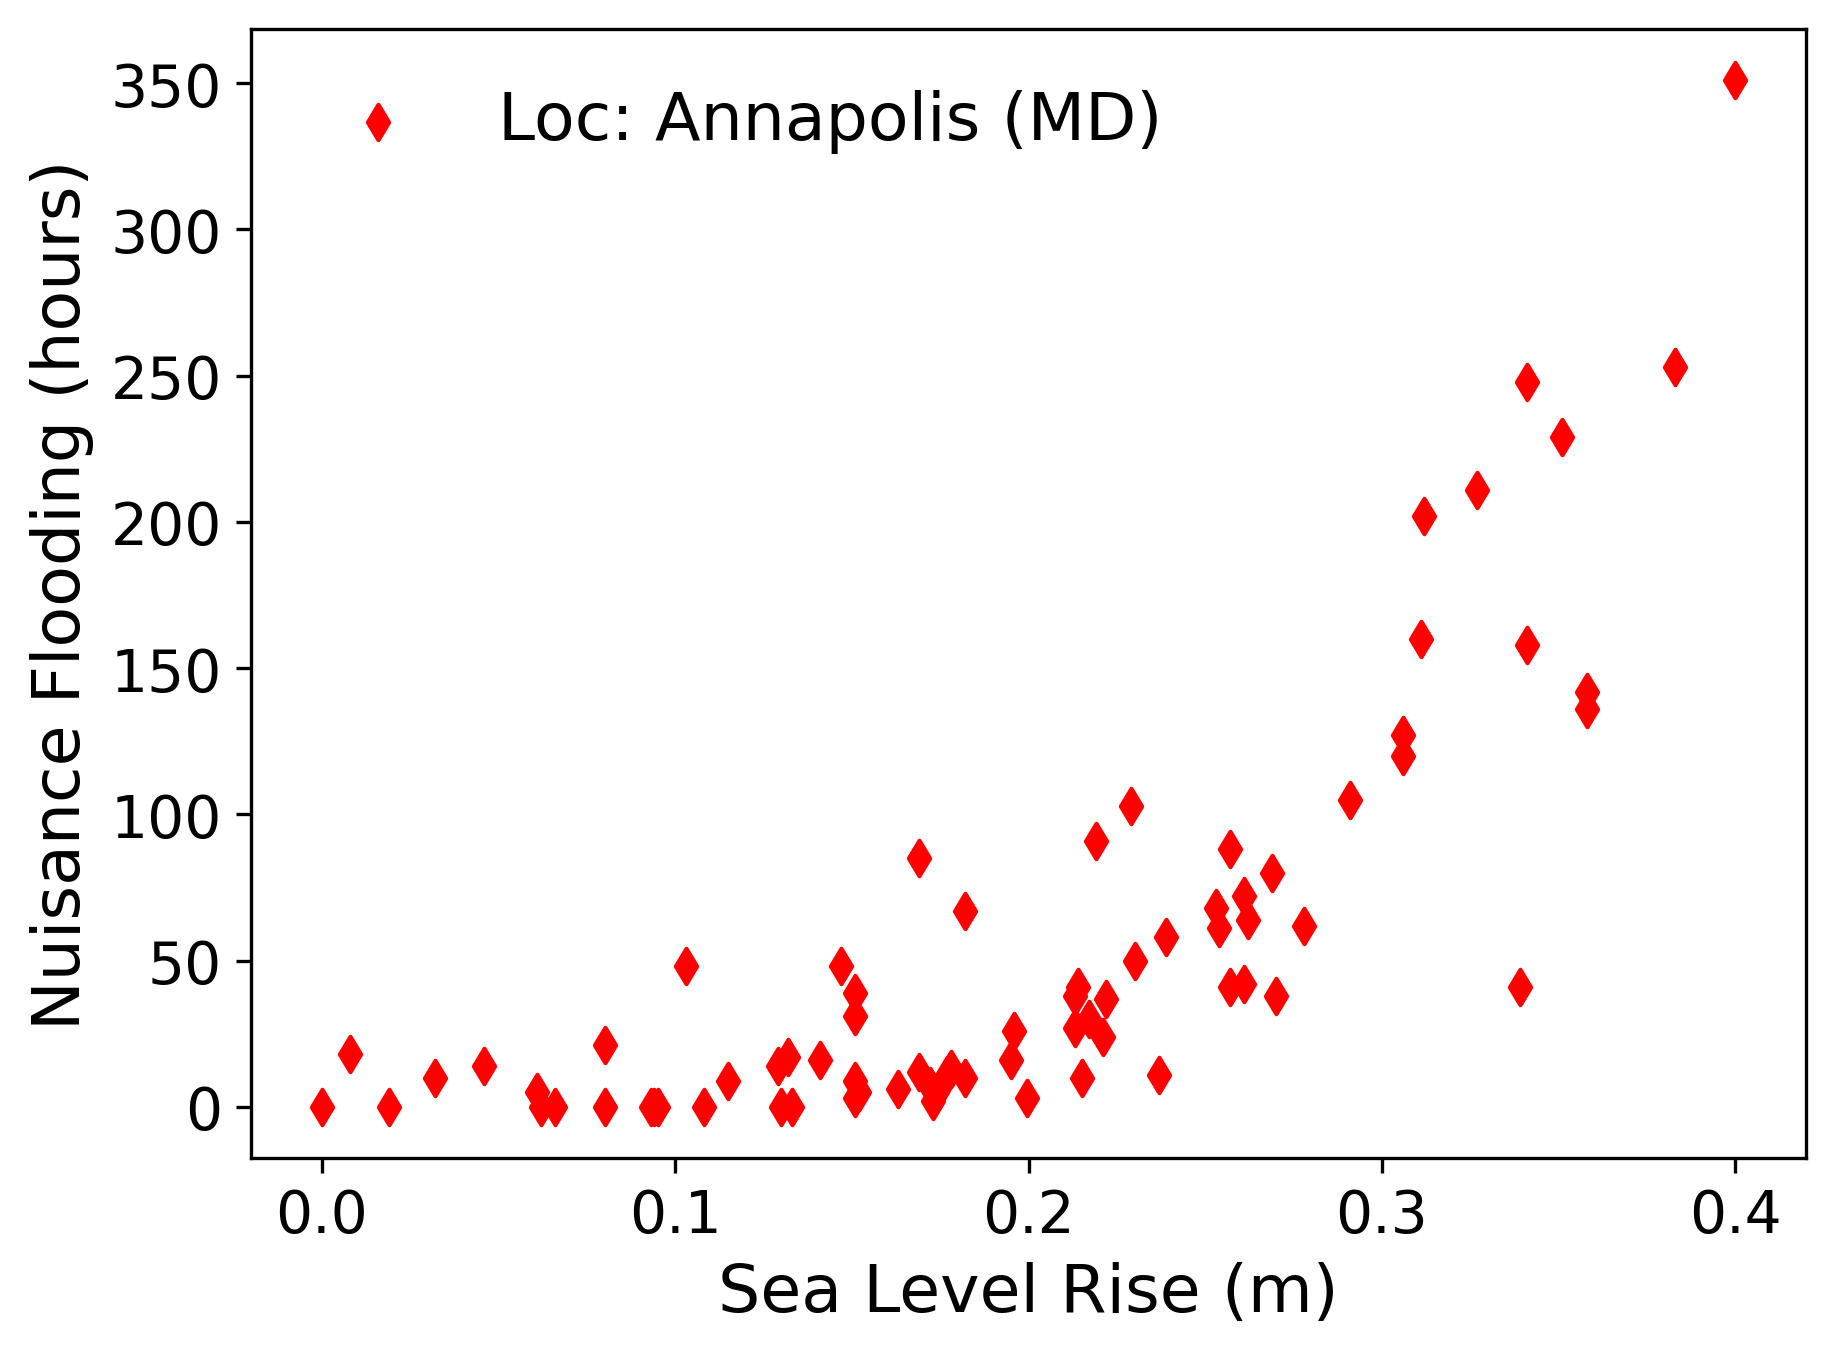

In [8]:
fig1 = plt.figure()
plt.scatter(data['AMD'], target['AMD'], marker = 'd', color = 'r', label = 'Loc: Annapolis (MD)')
plt.xlabel('Sea Level Rise (m)')
plt.ylabel('Nuisance Flooding (hours)')
plt.legend(frameon=False)
plt.tight_layout()
#plt.savefig('Annapolis.png')

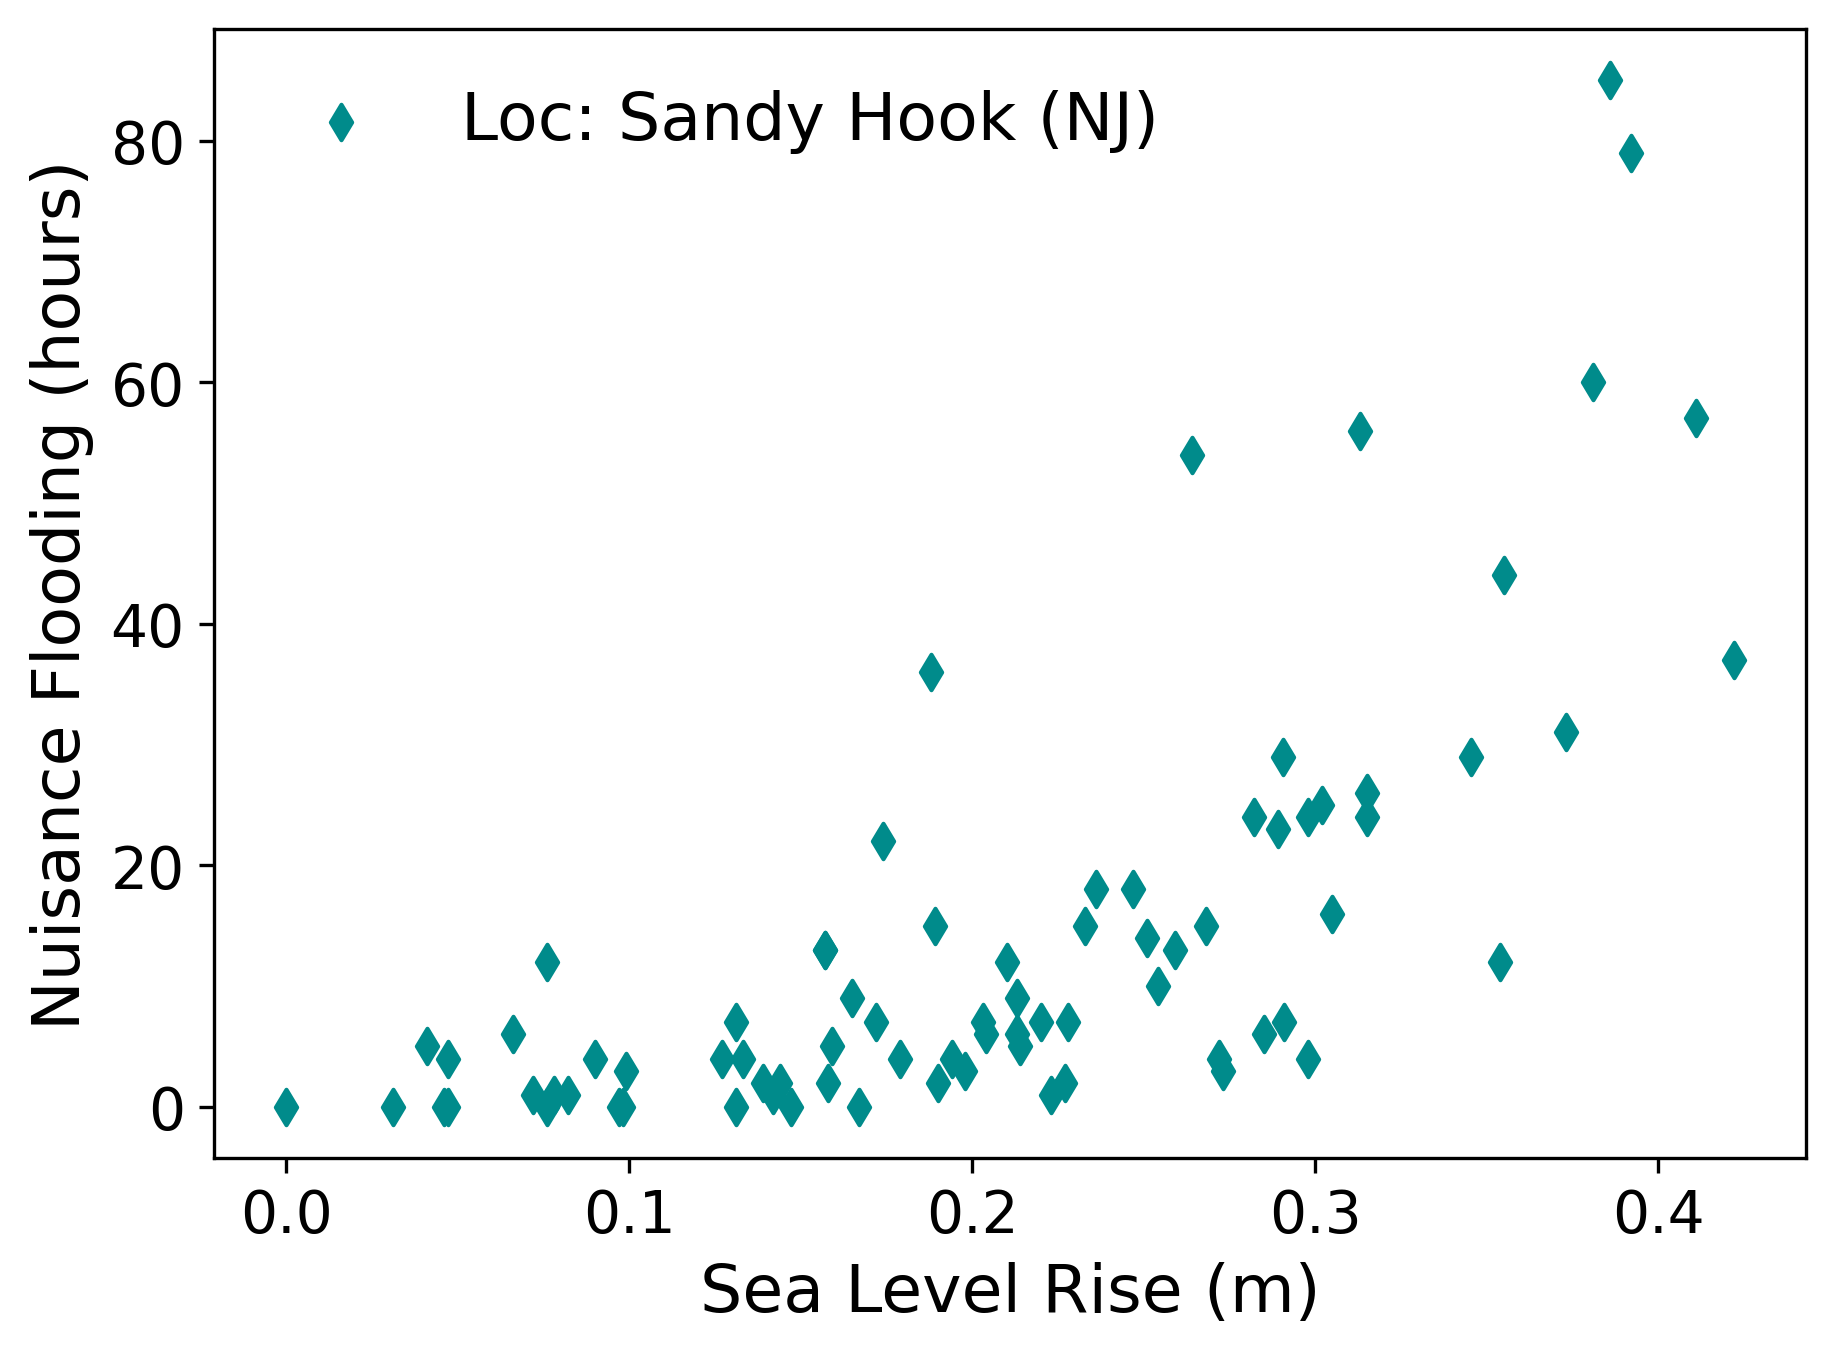

In [9]:
fig2 = plt.figure()
plt.scatter(data['SNJ'], target['SNJ'], marker = 'd', color = 'darkcyan', label = 'Loc: Sandy Hook (NJ)')
plt.xlabel('Sea Level Rise (m)')
plt.ylabel('Nuisance Flooding (hours)')
plt.legend(frameon=False)
plt.tight_layout()
#plt.savefig('SandyHook.png')

#### Let's start by analysing data for the Annapolis station.

In [10]:
len(np.where(np.isnan(data['AMD']))[0])/len(data['AMD']) # fraction of missing features

0.1276595744680851

In [11]:
len(np.where(np.isnan(target['AMD']))[0])/len(target['AMD'].values) # fraction of missing targets

0.1702127659574468

In [12]:
target['AMD'].values

array([ nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  18.,   0.,
         0.,  14.,  21.,  10.,   0.,   5.,  nan,   0.,   0.,   0.,   0.,
         9.,   0.,   0.,  nan,  nan,  17.,   5.,   0.,  48.,  31.,  39.,
         6.,  14.,  48.,   2.,  16.,  nan,   3.,  10.,  67.,  26.,   0.,
         9.,   5.,  12.,  16.,  11.,  nan,  30.,  24.,  68.,  nan,  41.,
        50.,   3.,  85.,  41.,  38.,   7.,  13.,  91., 105.,  38., 103.,
        58.,  42.,  10.,  27.,  37.,  61.,  80.,  62.,  11.,  88., 158.,
       160.,  41.,  53.,  nan,  39.,  64., 120., 202., 142., 211.,  72.,
       127., 248., 229., 351., 253., 136.])

In [13]:
data_amd = pd.concat([data['AMD'],target['AMD']], axis=1)
data_amd.columns = ['Sea Level', 'NF hours']
data_amd.head()

,Sea Level,NF hours
1920,NaN,NaN
1921,NaN,NaN
1922,NaN,NaN
1923,NaN,NaN
1924,NaN,NaN


We can drop years without available data.

In [14]:
new_data_amd = data_amd.dropna(how = 'any')
new_data_amd.head()

,Sea Level,NF hours
1929,0.008,18.0
1930,0.000,0.0
1931,0.019,0.0
1932,0.046,14.0
1933,0.080,21.0


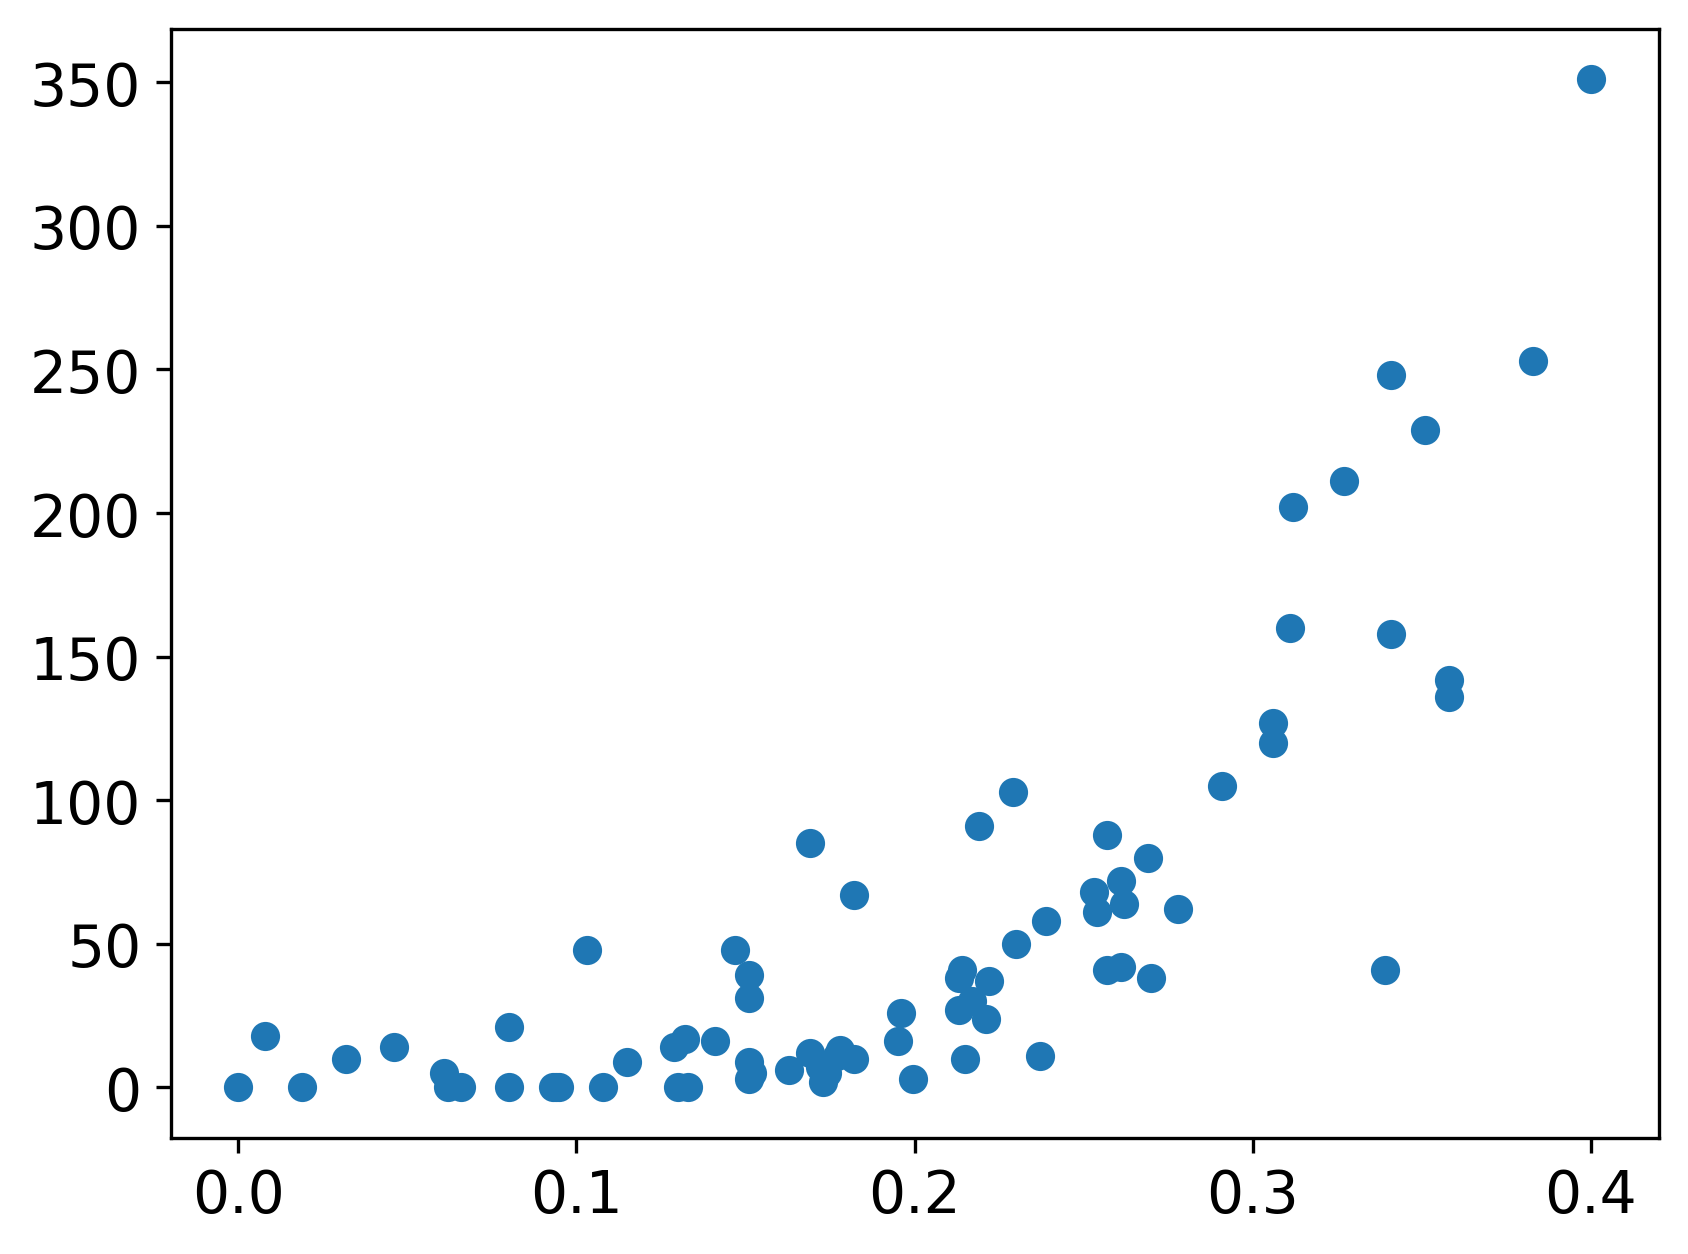

In [15]:
fig3 = plt.figure()
plt.scatter(new_data_amd['Sea Level'], new_data_amd['NF hours'])

### Note that because data are time-ordered, we won't do the usual random train test split or CV, but we will take data up to 2000 as train set, and the following years as test.

In [16]:
XTrain = new_data_amd['Sea Level'][new_data_amd.index < 2000]
YTrain = new_data_amd['NF hours'][new_data_amd.index < 2000]

XTest = new_data_amd['Sea Level'][new_data_amd.index > 2000]
YTest = new_data_amd['NF hours'][new_data_amd.index > 2000]

Just for fun, we can see what happens with Linear Regression.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [18]:
model = LinearRegression()

In [19]:
model.fit(XTrain.values.reshape(-1, 1),YTrain) #For YTrain it's not necessary to add "values"
YPred = model.predict(XTest.values.reshape(-1, 1))
model.coef_, model.intercept_

(array([308.22398004]), np.float64(-21.240498565959776))

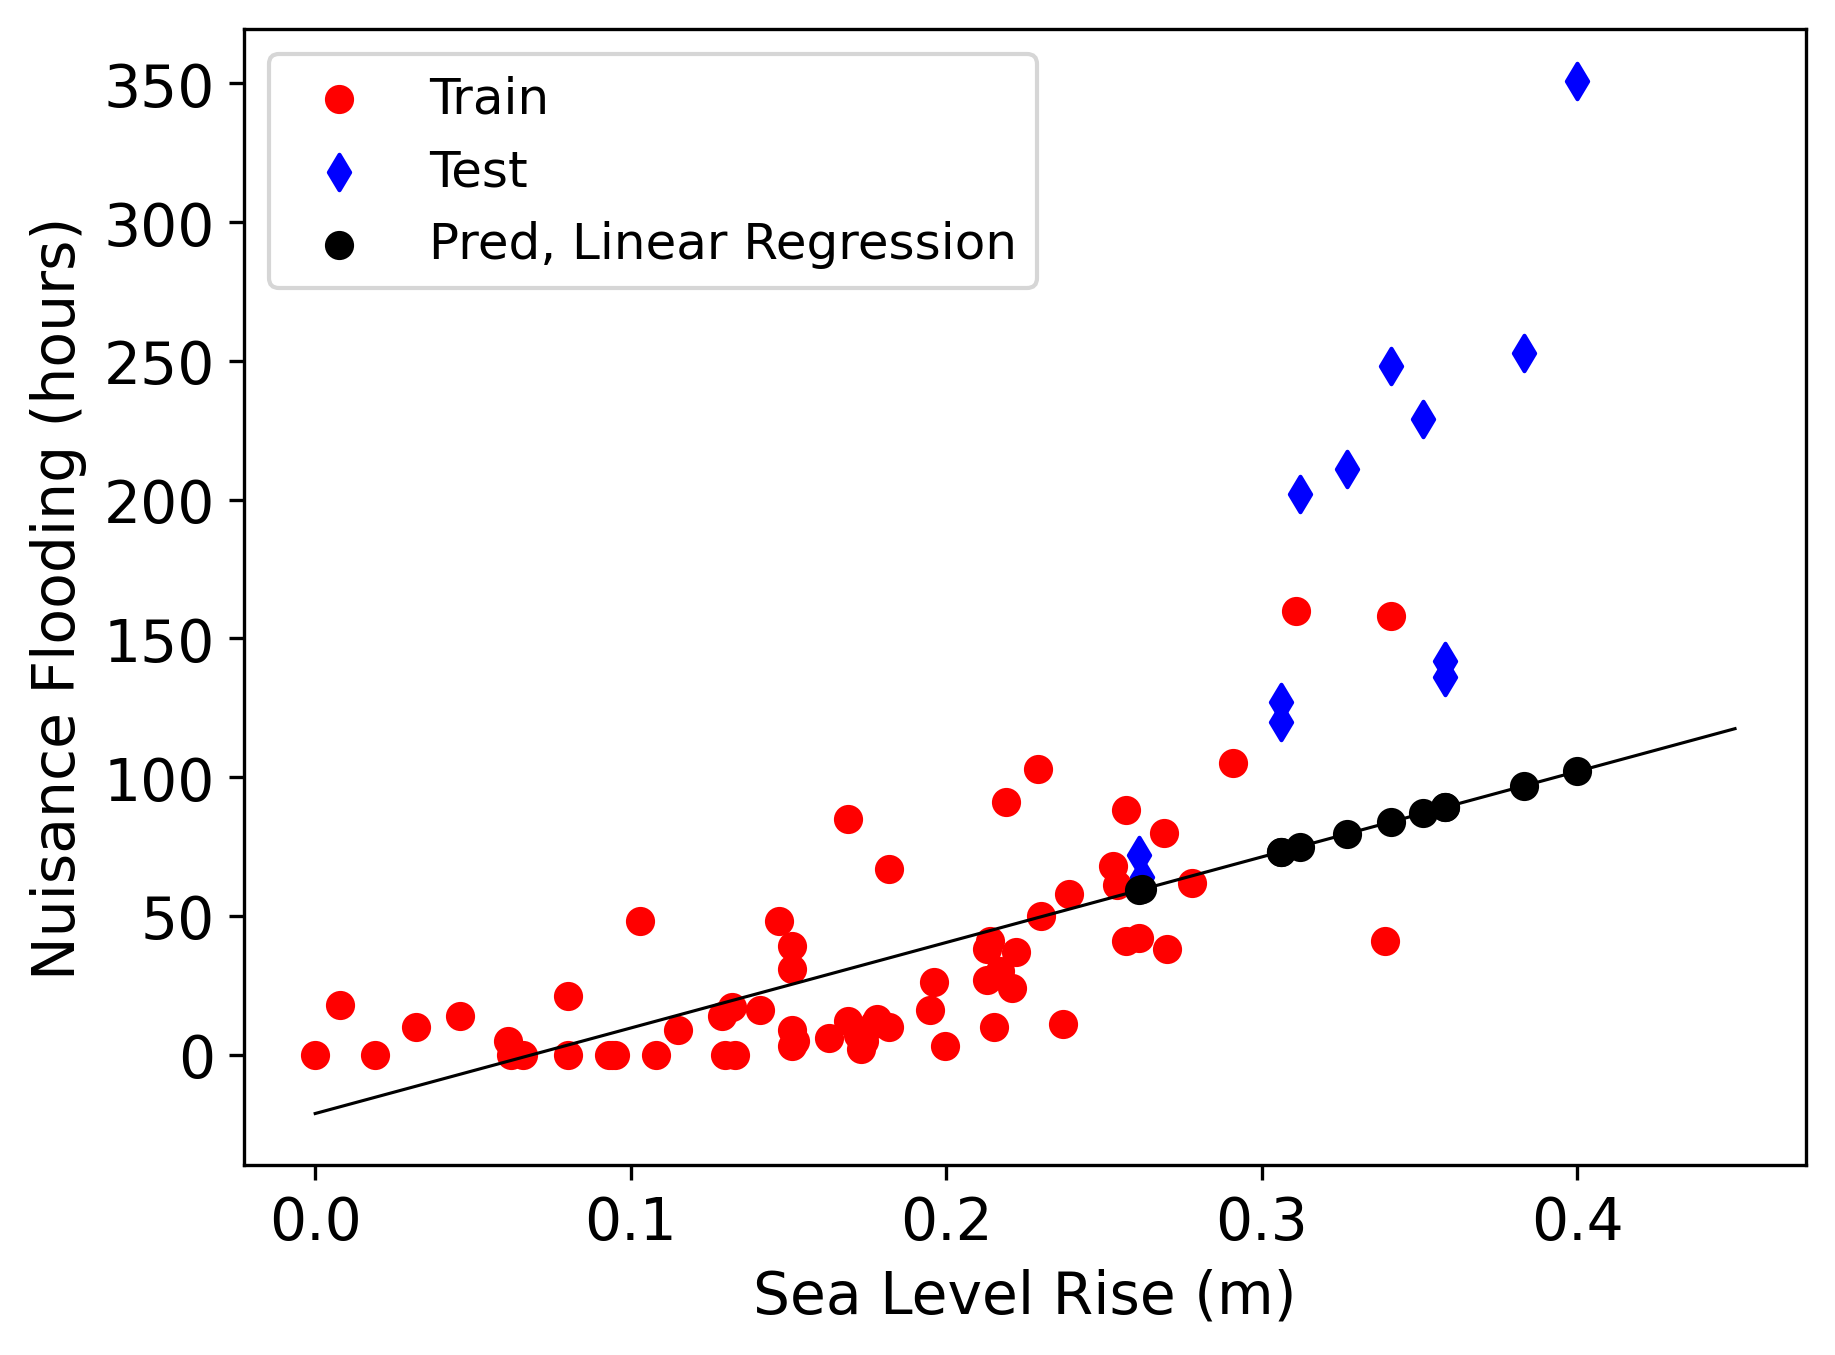

In [20]:
fig4 = plt.figure()
plt.scatter(XTrain.values, YTrain.values, c = 'r', marker = 'o', label = 'Train')
plt.scatter(XTest.values, YTest.values, c = 'b', marker = 'd', label = 'Test')
plt.scatter(XTest.values, YPred, c = 'k', label = 'Pred, Linear Regression')
y = np.linspace(0,0.45,50)
plt.plot(y, model.predict(y.reshape(-1,1)), c ='k', lw = 0.75)
plt.xlabel('Sea Level Rise (m)',fontsize=14)
plt.ylabel('Nuisance Flooding (hours)',fontsize=14)
plt.tight_layout()
plt.legend(fontsize=12);
#plt.savefig('Annapolis_LR.png')

### Unsurprisingly, the model performs pretty poorly; in fact, worse than the mean.

In [21]:
metrics.r2_score(YTest.values, YPred) #R^2 is negative :) 

-1.2734728883787603

In [22]:
metrics.mean_absolute_error(YTest.values, YPred)

98.98149182861208

In [23]:
metrics.r2_score(YTrain.values, model.predict(XTrain.values.reshape(-1,1)))

0.45078907163092385

### Let's move on to generalized linear models.

One possibility to train a GLM with Poisson exponential family and log link is to use statsmodels. It implements a IRLS (Iterative Reweighted Least Squares) without regularization.

In [24]:
#! pip install statsmodels
import statsmodels.api as sm

In [25]:
XTrain_GLM = sm.add_constant(XTrain.values.reshape(-1,1), prepend=False) #This allows one to fit for intercept
XTest_GLM = sm.add_constant(XTest.values.reshape(-1,1), prepend=False) #This allows one to fit for intercept
P_model = sm.GLM(YTrain, XTrain_GLM, family=sm.families.Poisson())
P_results = P_model.fit()
print(P_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               NF hours   No. Observations:                   64
Model:                            GLM   Df Residuals:                       62
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -689.34
Date:                Tue, 10 Mar 2026   Deviance:                       1112.8
Time:                        12:25:32   Pearson chi2:                 1.17e+03
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            10.6626      0.314     33.918      0.0

We can now use the model to make predictions:

In [26]:
P_results.predict(XTest_GLM) # in agreement with paper (actually, with results in repository)

array([ 59.4044343 ,  94.96626144, 101.24031723, 165.33521311,
       118.7993015 ,  58.7743956 ,  94.96626144, 137.92518792,
       153.44421188, 258.734565  , 215.84036956, 165.33521311])

The paper reports the mean absolute error of the Poisson model for each station, so we can compare this number directly with the published result:

In [27]:
metrics.mean_absolute_error(YTest.values.reshape(-1,1), P_results.predict(XTest_GLM)) #Agrees with paper!

52.964593361931236

One could also use the R2 score to estimate how good the model is, but remembers its caveats! If there is a lot of scatter in the response value, the R2 score will suffer even if the model is the best one possible.

In [28]:
metrics.r2_score(YTest.values.reshape(-1,1), P_results.predict(XTest_GLM)) 

0.3633315362938625

This is a reminder that the R2 score doesn't have an absolute meaning, for example transforming the y variable gives the illusion of a better R2 value even if the model is identical.

In [29]:
metrics.r2_score(np.log(YTest.values.reshape(-1,1)), np.log(P_results.predict(XTest_GLM))) #Agrees with paper!

0.42807398364175

### Here we visualize the predictions of the Poisson regression model.

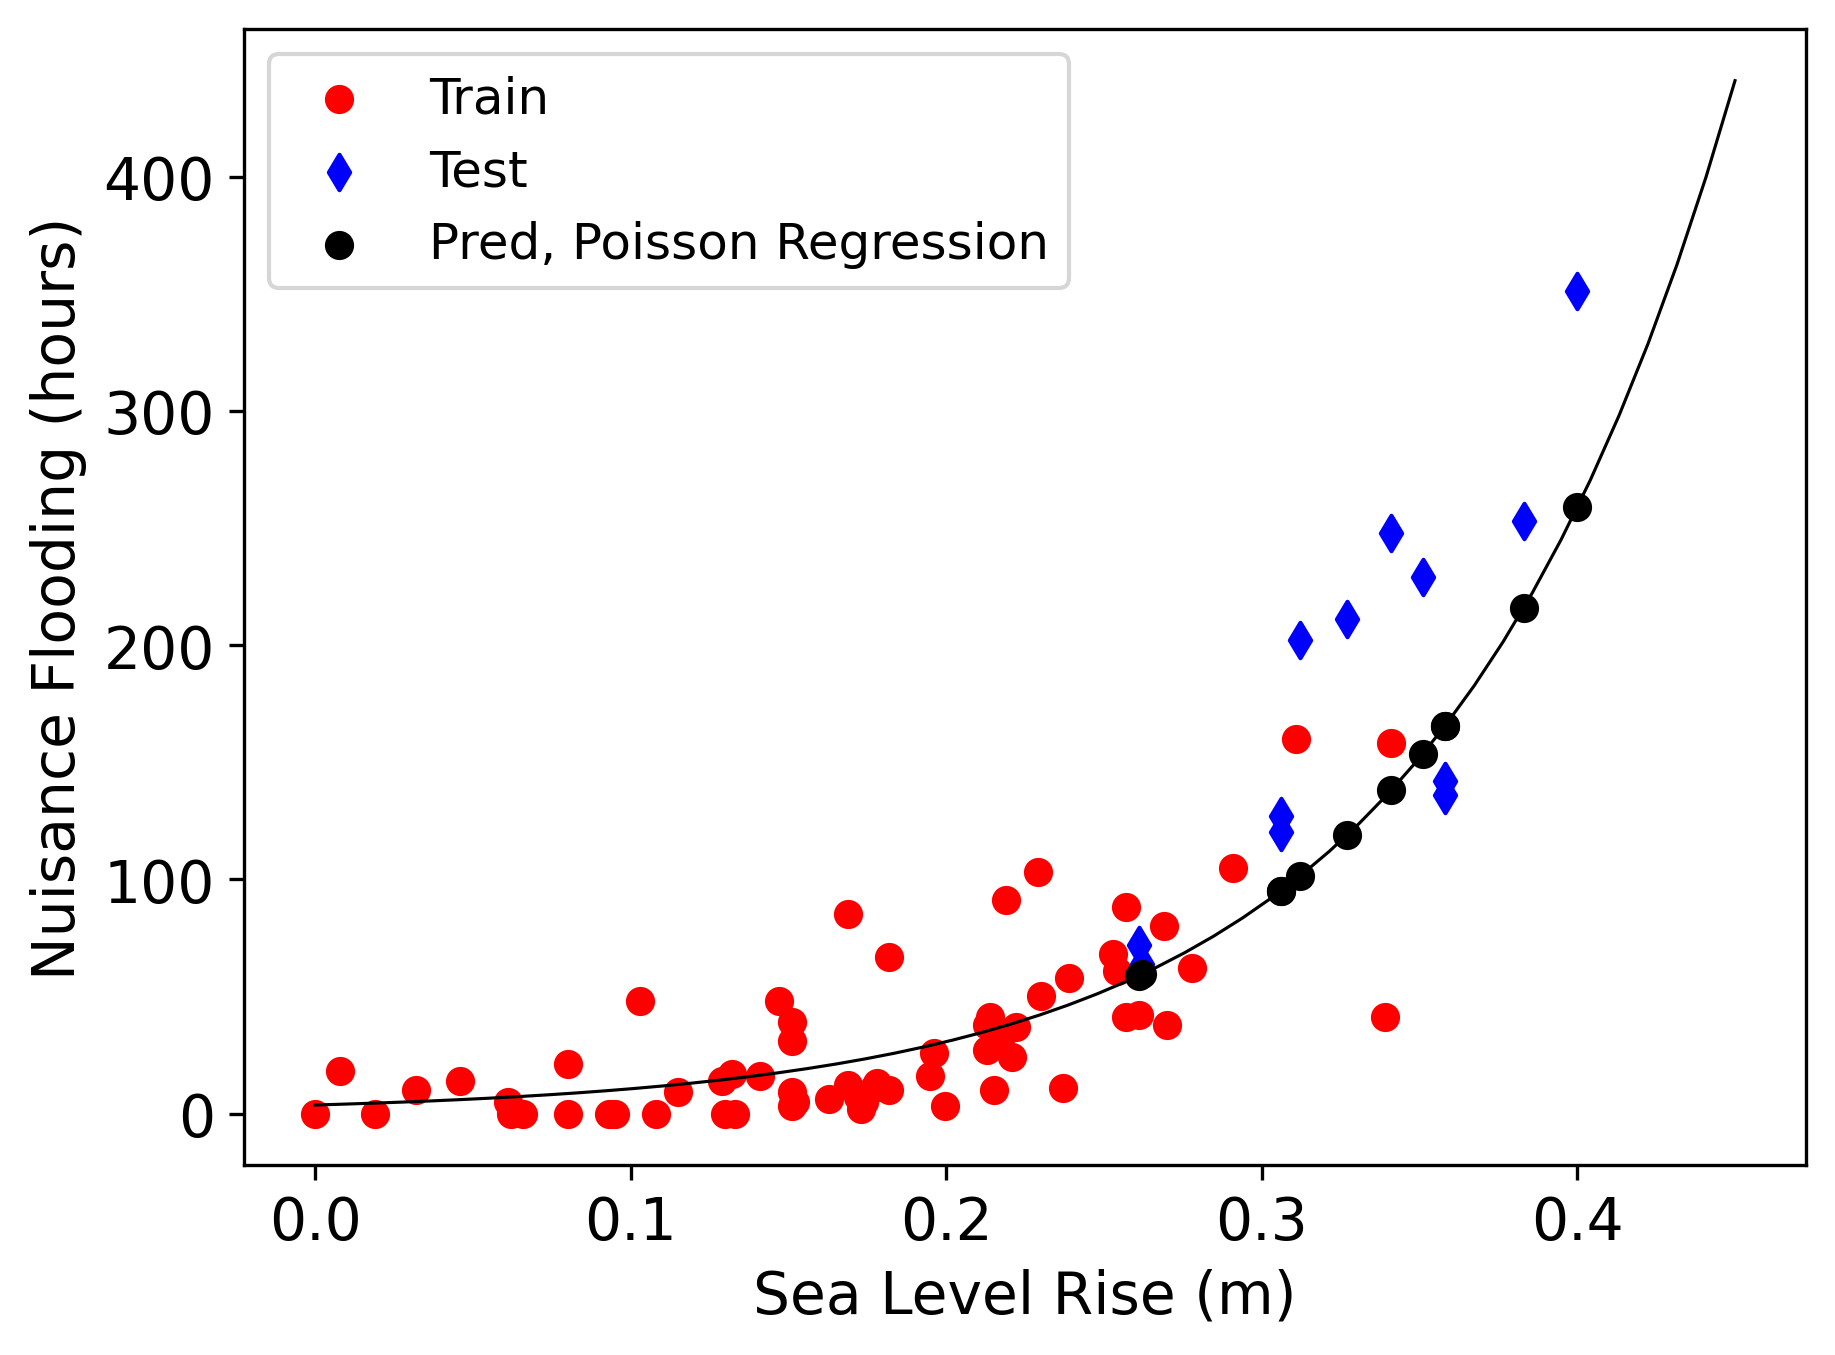

In [30]:
fig5 = plt.figure()
plt.scatter(XTrain.values, YTrain.values, c = 'r', marker = 'o', label = 'Train')
plt.scatter(XTest.values, YTest.values, c = 'b', marker = 'd', label = 'Test')
y = np.linspace(0,0.45,50)
plt.plot(y, P_results.predict(sm.add_constant(y, prepend=False)), c ='k', lw = 0.75)
plt.scatter(XTest.values, P_results.predict(XTest_GLM), c = 'k', label = 'Pred, Poisson Regression')
plt.legend(fontsize=12)
plt.xlabel('Sea Level Rise (m)',fontsize=14)
plt.ylabel('Nuisance Flooding (hours)',fontsize=14)
plt.tight_layout()
#plt.savefig('Annapolis_PR.png')

### We can now experiment with the sklearn GLM library.

In [31]:
from sklearn.linear_model import PoissonRegressor

In [32]:
PRmodel = PoissonRegressor(alpha = 0) #no regularization, for comparison
PRmodel.get_params()

{'alpha': 0,
 'fit_intercept': True,
 'max_iter': 100,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [33]:
PRmodel.fit(XTrain.values.reshape(-1, 1),YTrain) #For YTrain it's not necessary to add "values"
YPred = PRmodel.predict(XTest.values.reshape(-1, 1))
YPred

array([ 59.40409678,  94.96497207, 101.23883367, 165.33142559,
       118.79724087,  58.77407221,  94.96497207, 137.92244905,
       153.4408895 , 258.72668792, 215.8344568 , 165.33142559])

These are exactly equivalent to those obtained by statsmodels.

In [34]:
P_results.predict(XTest_GLM) 

array([ 59.4044343 ,  94.96626144, 101.24031723, 165.33521311,
       118.7993015 ,  58.7743956 ,  94.96626144, 137.92518792,
       153.44421188, 258.734565  , 215.84036956, 165.33521311])

### Here below we implement the Negative Binomial model; our results are not in agreement with those of the paper, perhaps because of a discrepancy in our data analysis pipeline or in the library implementation.

In [35]:
NB_model = sm.GLM(YTrain, XTrain_GLM, family=sm.families.NegativeBinomial())
NB_results = NB_model.fit()
print(NB_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               NF hours   No. Observations:                   64
Model:                            GLM   Df Residuals:                       62
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -266.11
Date:                Tue, 10 Mar 2026   Deviance:                       86.853
Time:                        12:28:13   Pearson chi2:                     60.8
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4690
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            10.3604      1.656      6.258      0.0

/Users/romanow/miniconda3/envs/euclid/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [36]:
NB_results.predict(XTest_GLM) # NOT in agreement with paper

array([ 57.937439  ,  91.39774159,  97.25954088, 156.64166918,
       113.61197024,  57.34028349,  91.39774159, 131.34589653,
       145.68374378, 242.03855746, 202.9521997 , 156.64166918])

In [37]:
metrics.mean_absolute_error(YTest.values.reshape(-1,1), NB_results.predict(XTest_GLM)) #This is lower than the one found in the paper.

56.77651867383969

<Figure size 1920x1440 with 0 Axes>

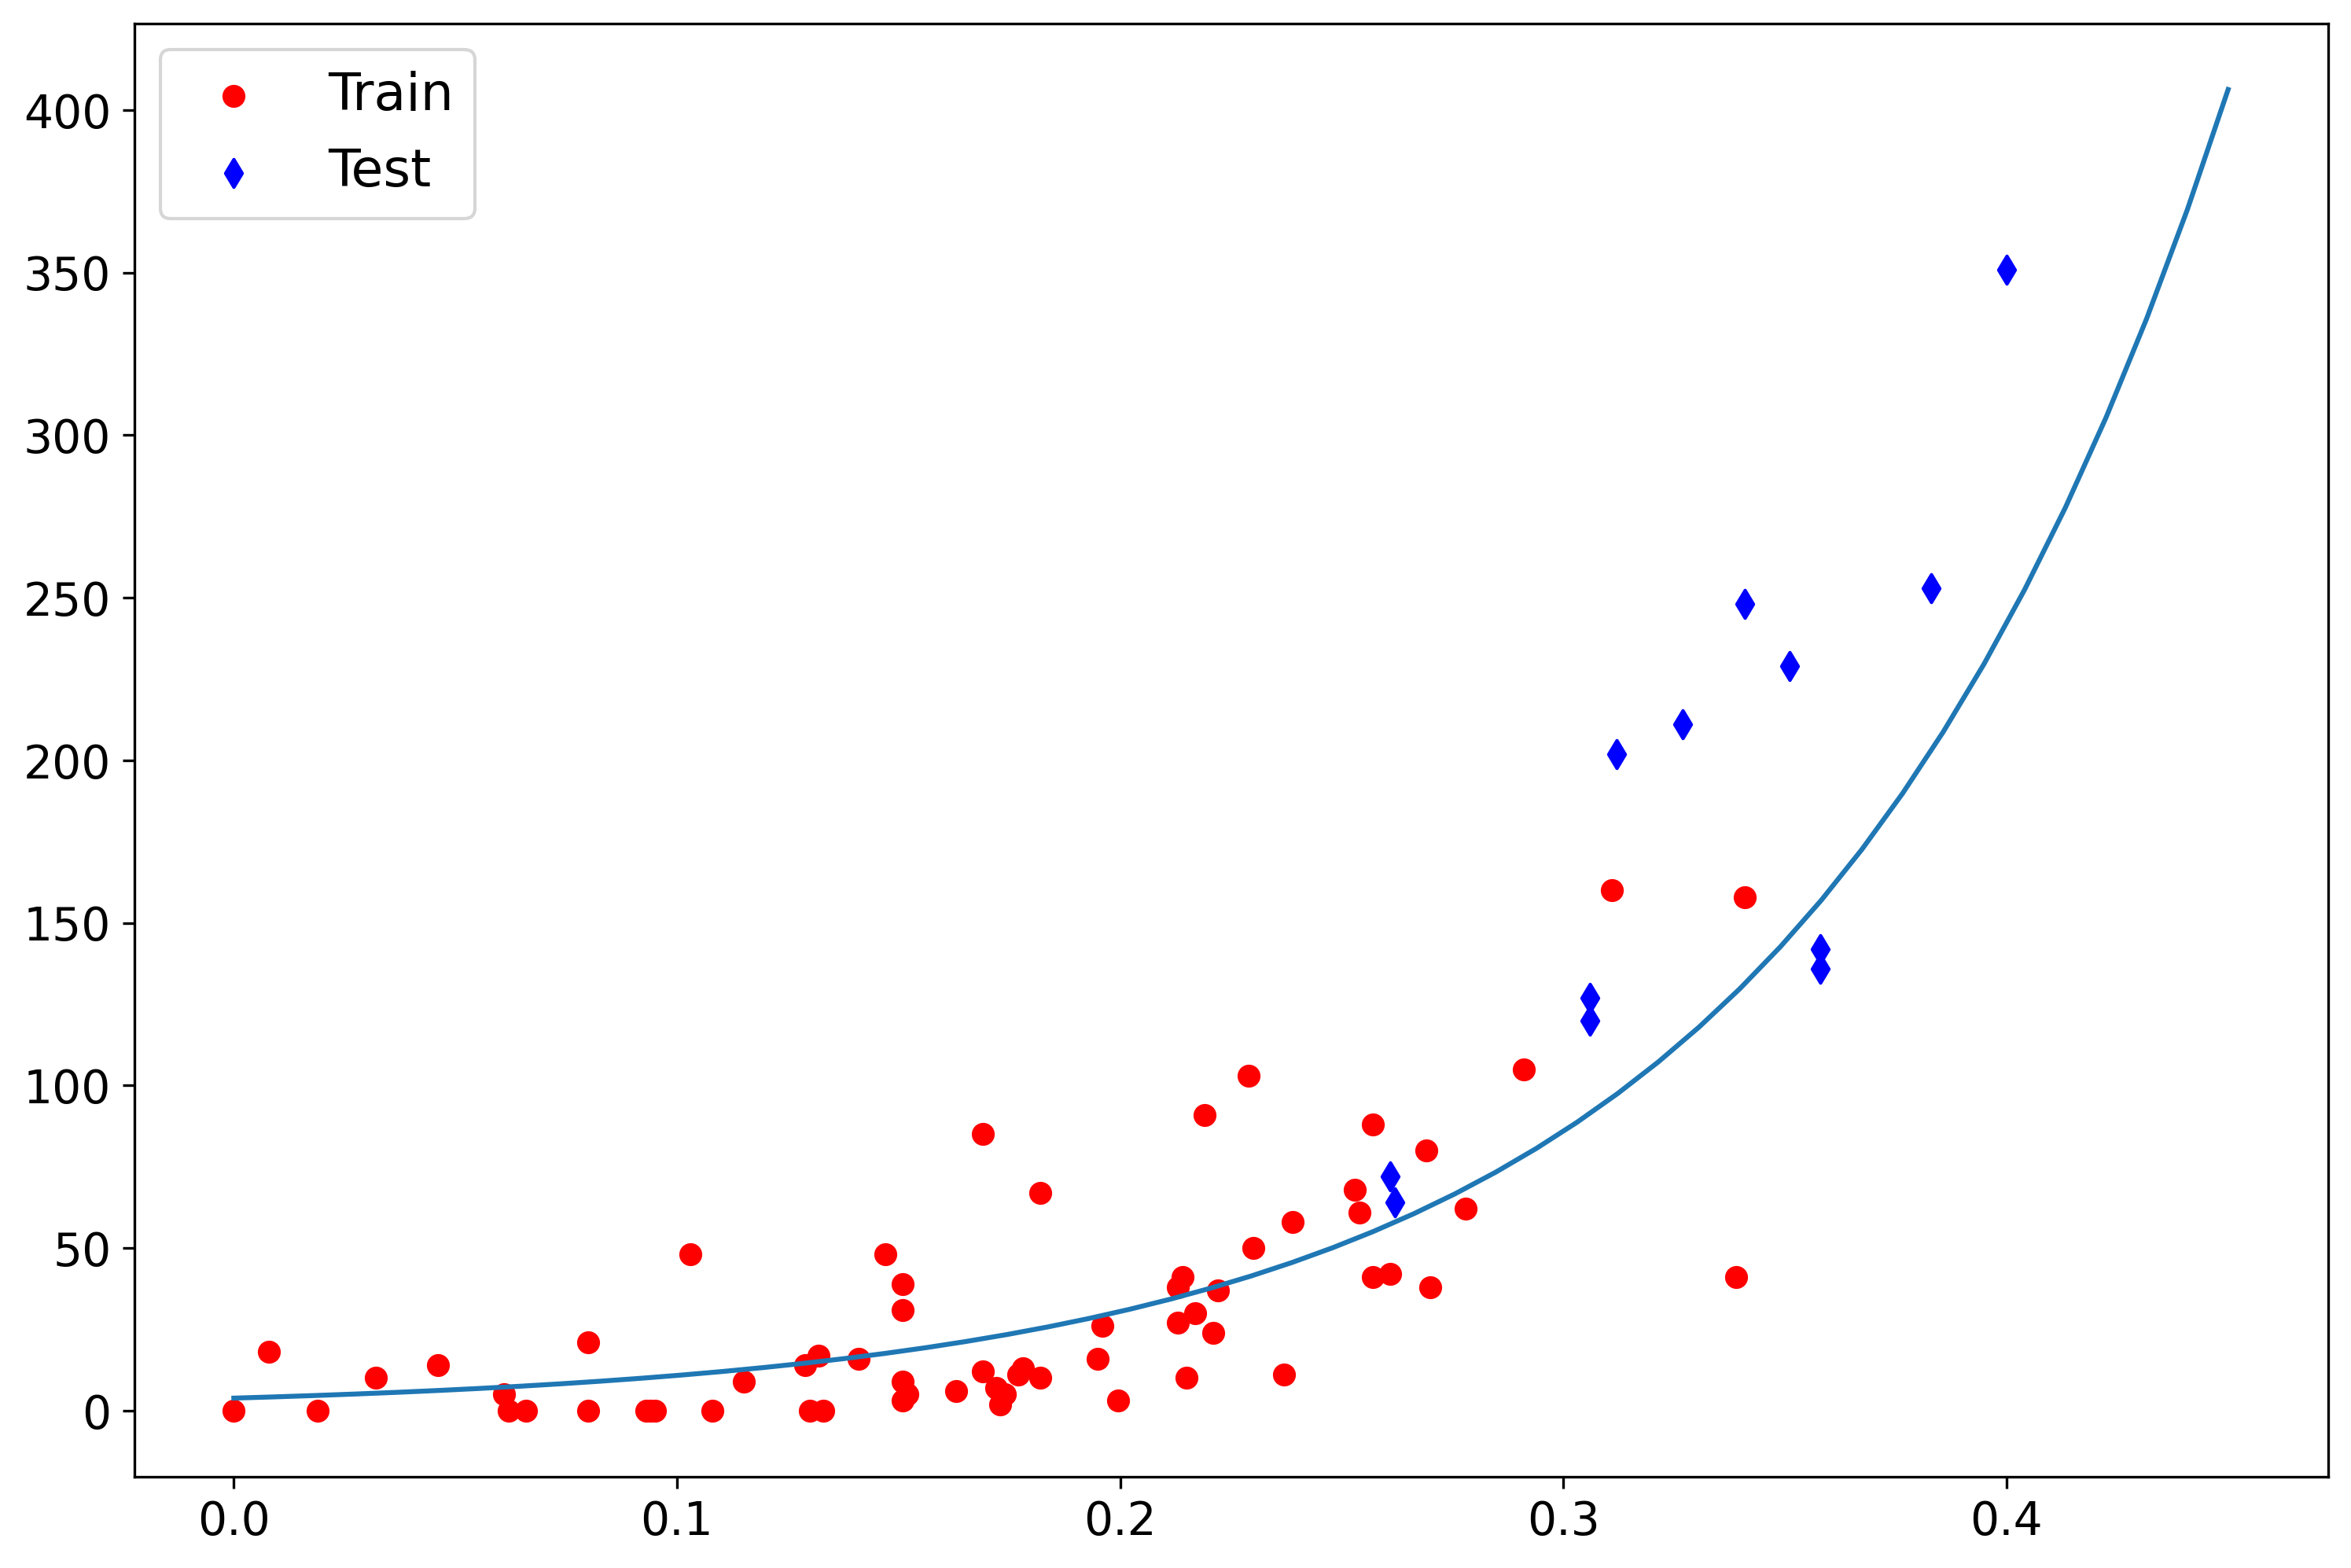

In [38]:
fig6 = plt.figure()
fig, ax = plt.subplots(figsize=(12, 8))
y = np.linspace(0,0.45,50)
plt.plot(y, NB_results.predict(sm.add_constant(y, prepend=False)))
plt.scatter(XTrain.values, YTrain.values, c = 'r', marker = 'o', label = 'Train')
plt.scatter(XTest.values, YTest.values, c = 'b', marker = 'd', label = 'Test')
plt.legend()